# LLM Technique Classification — Evaluation
Evaluates LLM output against gold labels using the same span-level scoring as the SemEval 2020 Task 11 scorer.
Compares against Experiment-2 (RoBERTa-large fine-tuned).

In [1]:
import ast, json, os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

RESULTS_CSV = "output/results.csv"
OUT_DIR     = "output"

def parse_list(s):
    try:
        v = ast.literal_eval(str(s))
        return v if isinstance(v, list) else []
    except Exception:
        return []

def score_overall(gold_dict, pred_dict):
    tp = fp = fn = 0
    for key in set(gold_dict) | set(pred_dict):
        g = gold_dict.get(key, set())
        p = pred_dict.get(key, set())
        tp += len(g & p); fp += len(p - g); fn += len(g - p)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return prec, rec, f1, tp, fp, fn

df = pd.read_csv(RESULTS_CSV)
df["gold_list"] = df["gold_techniques"].apply(parse_list)
df["pred_list"] = df["predicted_techniques"].apply(parse_list)

gold_dict = {}
pred_dict = {}
for _, row in df.iterrows():
    key = (str(row["article_id"]), int(row["idx"]))
    gold_dict[key] = set(row["gold_list"])
    pred_dict[key] = set(row["pred_list"])

print(f"Loaded {len(df):,} spans")

Loaded 11,001 spans


## 1 — Overall Metrics

In [2]:
prec, rec, f1, tp, fp, fn = score_overall(gold_dict, pred_dict)
exact = df["exact_match"].mean()
empty_pred = (df["pred_list"].apply(len) == 0).sum()

summary = pd.DataFrame([
    {"Metric": "Spans evaluated",    "Value": f"{len(df):,}"},
    {"Metric": "Empty predictions",  "Value": f"{empty_pred}"},
    {"Metric": "Exact match rate",   "Value": f"{exact:.4f}"},
    {"Metric": "Precision",          "Value": f"{prec:.4f}"},
    {"Metric": "Recall",             "Value": f"{rec:.4f}"},
    {"Metric": "Micro F1",           "Value": f"{f1:.4f}"},
    {"Metric": "TP / FP / FN",       "Value": f"{tp} / {fp} / {fn}"},
])
display(summary.set_index("Metric"))

,Value
Metric,
Spans evaluated,"11,001"
Empty predictions,205
Exact match rate,0.4256
Precision,0.4714
Recall,0.6163
Micro F1,0.5342
TP / FP / FN,6803 / 7630 / 4235


## 2 — Per-Technique F1

In [3]:
all_labels = sorted(
    {t for s in gold_dict.values() for t in s} |
    {t for s in pred_dict.values() for t in s}
)
all_keys = set(gold_dict) | set(pred_dict)

rows = []
for label in all_labels:
    tp_c = fp_c = fn_c = 0
    for key in all_keys:
        g = gold_dict.get(key, set())
        p = pred_dict.get(key, set())
        if   label in g and label in p:      tp_c += 1
        elif label not in g and label in p:  fp_c += 1
        elif label in g and label not in p:  fn_c += 1
    p_c  = tp_c / (tp_c + fp_c + 1e-9)
    r_c  = tp_c / (tp_c + fn_c + 1e-9)
    f1_c = 2 * p_c * r_c / (p_c + r_c + 1e-9)
    rows.append({
        "Technique":   label,
        "F1":          round(f1_c, 4),
        "Precision":   round(p_c,  4),
        "Recall":      round(r_c,  4),
        "Gold count":  sum(1 for g in gold_dict.values() if label in g),
        "Pred count":  sum(1 for p in pred_dict.values() if label in p),
        "TP": tp_c, "FP": fp_c, "FN": fn_c,
    })

per_tech_df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(per_tech_df[["Technique","F1","Precision","Recall","Gold count","Pred count","TP","FP","FN"]])

,Technique,F1,Precision,Recall,Gold count,Pred count,TP,FP,FN
0,Loaded_Language,0.6239,0.4852,0.8737,3799,6841,3319,3522,480
1,"Name_Calling,Labeling",0.5730,0.5340,0.6183,1881,2178,1163,1015,718
2,Doubt,0.5720,0.5766,0.5676,962,947,546,401,416
3,Flag-Waving,0.5634,0.5976,0.5329,471,420,251,169,220
4,Slogans,0.4960,0.4864,0.5061,247,257,125,132,122
5,"Exaggeration,Minimisation",0.4957,0.4230,0.5986,862,1220,516,704,346
6,Appeal_to_fear-prejudice,0.4156,0.3449,0.5227,551,835,288,547,263
7,"Whataboutism,Straw_Men,Red_Herring",0.3905,0.4552,0.3420,193,145,66,79,127
8,Appeal_to_Authority,0.3750,0.2840,0.5517,261,507,144,363,117
9,"Bandwagon,Reductio_ad_hitlerum",0.3346,0.3214,0.3488,129,140,45,95,84


## 3 — LLM vs Experiment-2 (RoBERTa-large) Comparison

In [4]:
exp2_f1 = {
    "Appeal_to_Authority":                 0.7273,
    "Appeal_to_fear-prejudice":            0.8435,
    "Bandwagon,Reductio_ad_hitlerum":      0.7333,
    "Black-and-White_Fallacy":             0.8421,
    "Causal_Oversimplification":           0.8824,
    "Doubt":                               0.8973,
    "Exaggeration,Minimisation":           0.8824,
    "Flag-Waving":                         0.8980,
    "Loaded_Language":                     0.9335,
    "Name_Calling,Labeling":               0.9211,
    "Repetition":                          0.8521,
    "Slogans":                             0.8283,
    "Thought-terminating_Cliches":         0.7692,
    "Whataboutism,Straw_Men,Red_Herring":  0.5974,
}

cmp_rows = []
for _, r in per_tech_df.iterrows():
    t  = r["Technique"]
    e2 = exp2_f1.get(t)
    cmp_rows.append({
        "Technique":      t,
        "LLM F1":         r["F1"],
        "Exp2 F1":        round(e2, 4) if e2 is not None else None,
        "Δ (LLM−Exp2)":  round(r["F1"] - e2, 4) if e2 is not None else None,
    })

cmp_rows.append({
    "Technique":     "── OVERALL (micro F1) ──",
    "LLM F1":        round(f1, 4),
    "Exp2 F1":       0.8878,
    "Δ (LLM−Exp2)": round(f1 - 0.8878, 4),
})

cmp_df = pd.DataFrame(cmp_rows)

def color_delta(val):
    if pd.isna(val): return ""
    return "color: red" if val < 0 else "color: green"

styler = cmp_df.set_index("Technique").style
# pandas >=2.1 uses .map(); older versions use .applymap()
try:
    styler = styler.map(color_delta, subset=["Δ (LLM−Exp2)"])
except AttributeError:
    styler = styler.applymap(color_delta, subset=["Δ (LLM−Exp2)"])

display(styler.format({"LLM F1": "{:.4f}", "Exp2 F1": "{:.4f}", "Δ (LLM−Exp2)": "{:+.4f}"}, na_rep="N/A"))
print("\n⚠️  LLM evaluated on 11,001 train+val spans; Exp2 on 1,661 test spans — indicative comparison only.")

,LLM F1,Exp2 F1,Δ (LLM−Exp2)
Technique,,,
Loaded_Language,0.6239,0.9335,-0.3096
"Name_Calling,Labeling",0.5730,0.9211,-0.3481
Doubt,0.5720,0.8973,-0.3253
Flag-Waving,0.5634,0.8980,-0.3346
Slogans,0.4960,0.8283,-0.3323
"Exaggeration,Minimisation",0.4957,0.8824,-0.3867
Appeal_to_fear-prejudice,0.4156,0.8435,-0.4279
"Whataboutism,Straw_Men,Red_Herring",0.3905,0.5974,-0.2069
Appeal_to_Authority,0.3750,0.7273,-0.3523



⚠️  LLM evaluated on 11,001 train+val spans; Exp2 on 1,661 test spans — indicative comparison only.


## 4 — F1 Bar Chart: LLM vs Experiment-2

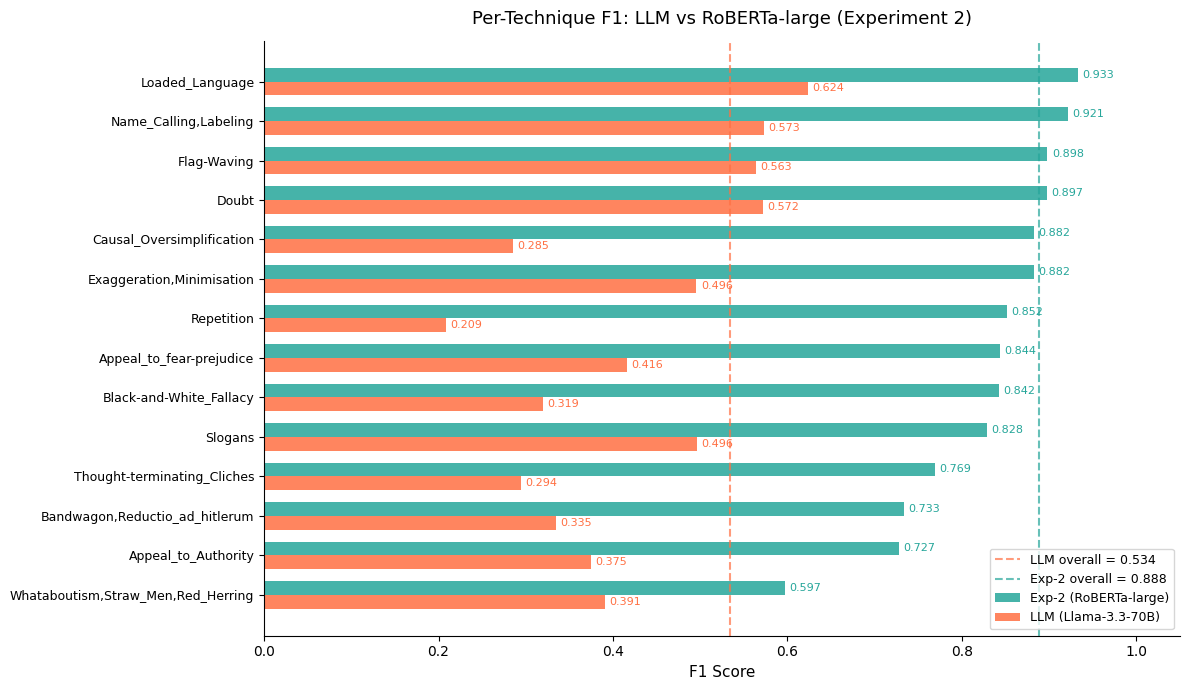

In [5]:
# Sort by Exp2 F1 for a clean chart
chart_df = cmp_df[cmp_df["Technique"] != "── OVERALL (micro F1) ──"].copy()
chart_df = chart_df.dropna(subset=["Exp2 F1"]).sort_values("Exp2 F1", ascending=True)

techs   = chart_df["Technique"].tolist()
llm_f1  = chart_df["LLM F1"].tolist()
exp2_f1_vals = chart_df["Exp2 F1"].tolist()

y    = np.arange(len(techs))
h    = 0.35
fig, ax = plt.subplots(figsize=(12, 7))

bars_exp2 = ax.barh(y + h/2, exp2_f1_vals, height=h, color="#26A69A", alpha=0.85, label="Exp-2 (RoBERTa-large)")
bars_llm  = ax.barh(y - h/2, llm_f1,       height=h, color="#FF7043", alpha=0.85, label="LLM (Llama-3.3-70B)")

for bar, v in zip(bars_exp2, exp2_f1_vals):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center", fontsize=8, color="#26A69A")
for bar, v in zip(bars_llm, llm_f1):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center", fontsize=8, color="#FF7043")

ax.set_yticks(y)
ax.set_yticklabels(techs, fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1 Score", fontsize=11)
ax.set_title("Per-Technique F1: LLM vs RoBERTa-large (Experiment 2)", fontsize=13, pad=12)
ax.axvline(f1,    color="#FF7043", lw=1.5, linestyle="--", alpha=0.7, label=f"LLM overall = {f1:.3f}")
ax.axvline(0.8878, color="#26A69A", lw=1.5, linestyle="--", alpha=0.7, label="Exp-2 overall = 0.888")
ax.legend(fontsize=9, loc="lower right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "llm_vs_exp2_f1.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5 — Gold vs Predicted Count per Technique

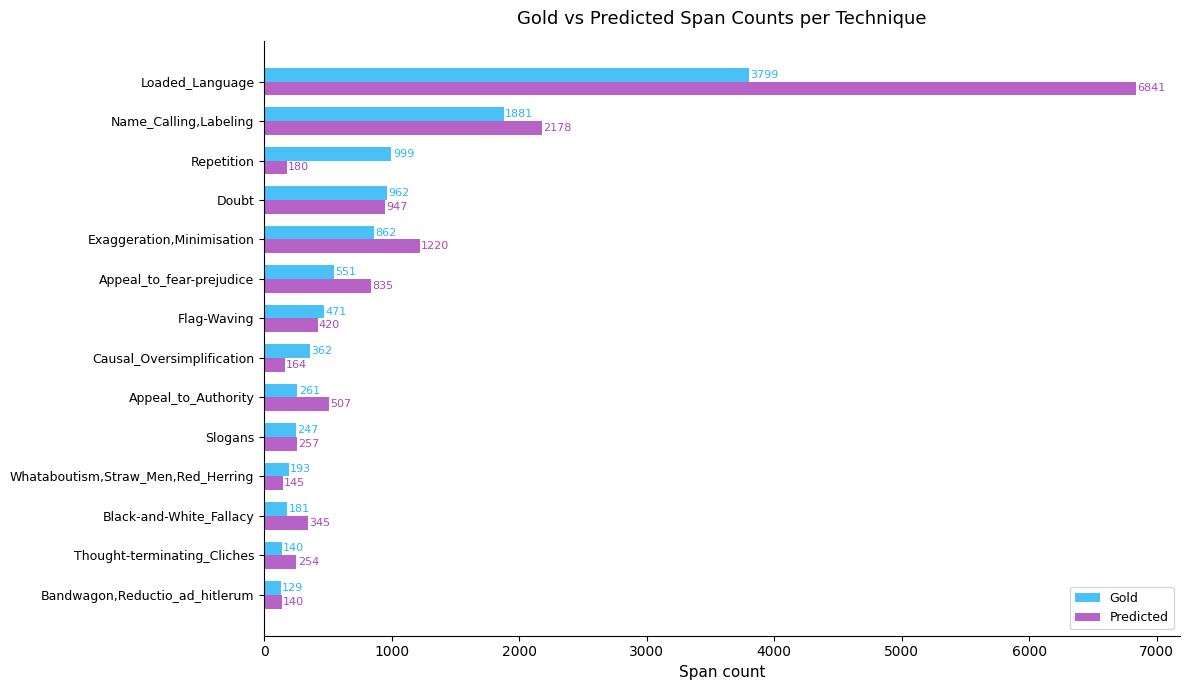


Over-predicted (pred >> gold):
  Thought-terminating_Cliches                    gold=140  pred=254  ratio=1.81x
  Black-and-White_Fallacy                        gold=181  pred=345  ratio=1.91x
  Appeal_to_Authority                            gold=261  pred=507  ratio=1.94x
  Appeal_to_fear-prejudice                       gold=551  pred=835  ratio=1.52x
  Exaggeration,Minimisation                      gold=862  pred=1220  ratio=1.42x
  Loaded_Language                                gold=3799  pred=6841  ratio=1.80x

Under-predicted (pred << gold):
  Causal_Oversimplification                      gold=362  pred=164  ratio=0.45x
  Repetition                                     gold=999  pred=180  ratio=0.18x


In [6]:
count_df = per_tech_df.sort_values("Gold count", ascending=True)
techs_c  = count_df["Technique"].tolist()
gold_c   = count_df["Gold count"].tolist()
pred_c   = count_df["Pred count"].tolist()

y2   = np.arange(len(techs_c))
fig2, ax2 = plt.subplots(figsize=(12, 7))
b_gold = ax2.barh(y2 + h/2, gold_c, height=h, color="#29B6F6", alpha=0.85, label="Gold")
b_pred = ax2.barh(y2 - h/2, pred_c, height=h, color="#AB47BC", alpha=0.85, label="Predicted")

for bar, v in zip(b_gold, gold_c):
    ax2.text(v + 10, bar.get_y() + bar.get_height()/2, str(v), va="center", fontsize=8, color="#29B6F6")
for bar, v in zip(b_pred, pred_c):
    ax2.text(v + 10, bar.get_y() + bar.get_height()/2, str(v), va="center", fontsize=8, color="#AB47BC")

ax2.set_yticks(y2)
ax2.set_yticklabels(techs_c, fontsize=9)
ax2.set_xlabel("Span count", fontsize=11)
ax2.set_title("Gold vs Predicted Span Counts per Technique", fontsize=13, pad=12)
ax2.legend(fontsize=9)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "llm_gold_vs_pred_counts.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nOver-predicted (pred >> gold):")
for _, r in count_df.iterrows():
    ratio = r["Pred count"] / max(r["Gold count"], 1)
    if ratio > 1.3:
        print(f"  {r['Technique']:<45}  gold={r['Gold count']}  pred={r['Pred count']}  ratio={ratio:.2f}x")
print("\nUnder-predicted (pred << gold):")
for _, r in count_df.iterrows():
    ratio = r["Pred count"] / max(r["Gold count"], 1)
    if ratio < 0.5:
        print(f"  {r['Technique']:<45}  gold={r['Gold count']}  pred={r['Pred count']}  ratio={ratio:.2f}x")

## 6 — Error Analysis: Where Does the LLM Fail?

In [7]:
# Confusion-style: most common wrong predictions for each gold technique
from collections import Counter

errors = []  # (gold_tech, pred_tech)
for _, row in df.iterrows():
    g_set = set(row["gold_list"])
    p_set = set(row["pred_list"])
    for gt in g_set - p_set:          # missed (FN)
        for pt in p_set - g_set:      # predicted instead
            errors.append((gt, pt))

error_counter = Counter(errors)
top_errors = pd.DataFrame(
    [(g, p, c) for (g, p), c in error_counter.most_common(20)],
    columns=["Gold (missed)", "Predicted instead", "Count"]
)
print("Top 20 confusion pairs (gold missed → predicted instead):")
display(top_errors)

Top 20 confusion pairs (gold missed → predicted instead):


,Gold (missed),Predicted instead,Count
0,"Name_Calling,Labeling",Loaded_Language,591
1,Repetition,Loaded_Language,506
2,Doubt,Loaded_Language,259
3,"Exaggeration,Minimisation",Loaded_Language,221
4,Repetition,"Name_Calling,Labeling",172
5,Loaded_Language,"Exaggeration,Minimisation",155
6,Appeal_to_fear-prejudice,Loaded_Language,153
7,Causal_Oversimplification,Loaded_Language,135
8,Flag-Waving,Loaded_Language,117
9,Causal_Oversimplification,Doubt,99


## 7 — Sample Predictions

In [8]:
# Show a sample of correct, wrong, and empty predictions
correct   = df[df["exact_match"] == True].sample(5, random_state=42)
wrong     = df[(df["exact_match"] == False) & (df["pred_list"].apply(len) > 0)].sample(10, random_state=42)
empty     = df[df["pred_list"].apply(len) == 0].head(5)

def show_sample(subset, title):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    for _, r in subset.iterrows():
        print(f"  Span    : {str(r['span_text'])[:80]}")
        print(f"  Gold    : {r['gold_list']}")
        print(f"  Pred    : {r['pred_list']}")
        print()

show_sample(correct, "✅ Correct predictions (exact match)")
show_sample(wrong,   "❌ Wrong predictions")
show_sample(empty,   "⚠️  Empty predictions (no label assigned)")


  ✅ Correct predictions (exact match)
  Span    : Did he know something that Stephen Paddock was going to do
  Gold    : ['Doubt']
  Pred    : ['Doubt']

  Span    : park” the priest out of harm’s way
  Gold    : ['Loaded_Language']
  Pred    : ['Loaded_Language']

  Span    : baffling observations
  Gold    : ['Loaded_Language']
  Pred    : ['Loaded_Language']

  Span    : so disillusioned the nation that it elected Barack Obama
  Gold    : ['Causal_Oversimplification']
  Pred    : ['Causal_Oversimplification']

  Span    : US power
  Gold    : ['Flag-Waving']
  Pred    : ['Flag-Waving']


  ❌ Wrong predictions
  Span    : grieving leftist Latinos
  Gold    : ['Name_Calling,Labeling']
  Pred    : ['Name_Calling,Labeling', 'Loaded_Language']

  Span    : The US Is Blatantly Telling Lies
  Gold    : ['Doubt']
  Pred    : ['Loaded_Language']

  Span    : left of center
  Gold    : ['Repetition']
  Pred    : ['Name_Calling,Labeling']

  Span    : In sum, the Guardian published a story to

## 8 — Save Results

In [9]:
metrics = {
    "num_spans":    len(df),
    "exact_match":  float(exact),
    "precision":    prec,
    "recall":       rec,
    "micro_f1":     f1,
    "tp": tp, "fp": fp, "fn": fn,
    "per_technique": {r["Technique"]: r["F1"] for _, r in per_tech_df.iterrows()},
    "note": "Evaluated on train+val spans (11001). Test set not yet run."
}
with open(os.path.join(OUT_DIR, "llm_metrics.json"), "w") as fh:
    json.dump(metrics, fh, indent=2)

per_tech_df.to_csv(os.path.join(OUT_DIR, "llm_per_technique_f1.csv"), index=False)
top_errors.to_csv(os.path.join(OUT_DIR, "llm_confusion_pairs.csv"), index=False)

print("Saved:")
print("  output/llm_metrics.json")
print("  output/llm_per_technique_f1.csv")
print("  output/llm_confusion_pairs.csv")
print("  output/llm_vs_exp2_f1.png")
print("  output/llm_gold_vs_pred_counts.png")

Saved:
  output/llm_metrics.json
  output/llm_per_technique_f1.csv
  output/llm_confusion_pairs.csv
  output/llm_vs_exp2_f1.png
  output/llm_gold_vs_pred_counts.png
